# Graph Construction — IBM AML HI-Medium

**Pipeline stage:** `preprocessing.ipynb` → **this notebook** → `train_gcn.ipynb` (GCN training)

**Goal:** load the arrays produced by `preprocessing.ipynb`, build the transaction graph
with NetworkX (for exploration/sanity-checking) and PyTorch Geometric (for the actual
model input), validate everything is internally consistent, and save a single
`torch_geometric.data.Data` object that `train_gcn.ipynb` can load directly.

**Recap of what's coming in from `preprocessing.ipynb`:**
- Nodes = accounts (`Bank_Account`), edges = transactions (edge classification framing)
- Node features are log-scaled + standardized (fit on train-active nodes only)
- Edge features: continuous amount features are log-scaled + standardized the same
  way (fit on train edges only); binary flags and sin/cos temporal features are left
  as-is; `Payment Format` / currency columns are categorical codes, not continuous
  values -- `edge_cat_start` marks where they begin in `edge_attr` so `train_gcn.ipynb`
  can route them to `nn.Embedding` instead of a linear layer
- `transaction_id` exists as a separate lookup array — it is **not** a graph feature
- Split is temporal-stratified per class (train/val/test each carry a similar
  laundering rate, ~0.11%)

This notebook doesn't retrain anything or touch the raw CSV again — everything it
needs was already computed and saved to `Bassam Data`.


In [2]:
# --- Config ---
import numpy as np
import pandas as pd
import json
import pickle
from pathlib import Path

DATA_DIR = Path("/home/jovyan/AML_Project/Data/Bassam Data")

assert DATA_DIR.exists(), f"{DATA_DIR} not found -- run preprocessing.ipynb first."


## 1. Load preprocessing artifacts

In [3]:
edge_index = np.load(DATA_DIR / "edge_index.npy")          # (2, E)
edge_attr = np.load(DATA_DIR / "edge_attr.npy")              # (E, F_e)
node_attr = np.load(DATA_DIR / "node_attr.npy")               # (N, F_n)
labels = np.load(DATA_DIR / "labels.npy")                     # (E,)
transaction_ids = np.load(DATA_DIR / "transaction_ids.npy", allow_pickle=True)  # (E,)

split_masks_npz = np.load(DATA_DIR / "split_masks.npz")
split_masks = {k: split_masks_npz[k] for k in split_masks_npz.files}

with open(DATA_DIR / "node_to_idx.json") as f:
    node_to_idx = json.load(f)
idx_to_node = {v: k for k, v in node_to_idx.items()}

with open(DATA_DIR / "encoders.pkl", "rb") as f:
    encoders = pickle.load(f)

with open(DATA_DIR / "node_scaler.pkl", "rb") as f:
    node_scaler = pickle.load(f)

with open(DATA_DIR / "edge_scaler.pkl", "rb") as f:
    edge_scaler = pickle.load(f)

with open(DATA_DIR / "metadata.json") as f:
    metadata = json.load(f)

# Where the categorical-code columns start within edge_attr -- train_gcn.ipynb needs
# this to split edge_attr[:, :edge_cat_start] (-> Linear) from
# edge_attr[:, edge_cat_start:] (-> nn.Embedding), per the note in preprocessing.ipynb
# Section 6b. Carried through metadata rather than hardcoded here so it can't drift
# out of sync with EDGE_FEATURE_COLS if that list changes.
edge_cat_start = metadata["edge_cat_start"]

transactions_lookup = pd.read_csv(DATA_DIR / "transactions_lookup.csv")

print(f"edge_index: {edge_index.shape}")
print(f"edge_attr : {edge_attr.shape}")
print(f"node_attr : {node_attr.shape}")
print(f"labels    : {labels.shape}")
print(f"transaction_ids: {transaction_ids.shape}")
print(f"nodes in node_to_idx: {len(node_to_idx):,}")
print(f"transactions_lookup: {transactions_lookup.shape}")


edge_index: (2, 31898218)
edge_attr : (31898218, 21)
node_attr : (2077023, 11)
labels    : (31898218,)
transaction_ids: (31898218,)
nodes in node_to_idx: 2,077,023
transactions_lookup: (31898218, 17)


## 2. Sanity checks

Cheap checks that catch a mismatched or corrupted artifact before it wastes an hour of
training later. All of these should pass silently -- if any assertion fails, stop and
go back to `preprocessing.ipynb` rather than working around it here.

In [4]:
n_nodes = node_attr.shape[0]
n_edges = edge_index.shape[1]

assert edge_index.shape[0] == 2, "edge_index must be shape (2, E)"
assert edge_index.max() < n_nodes, "edge_index references a node index out of range"
assert edge_index.min() >= 0, "edge_index has a negative node index"
assert edge_attr.shape[0] == n_edges == labels.shape[0] == transaction_ids.shape[0], \
    "edge_attr / labels / transaction_ids must all have exactly E rows, in the same order"
assert n_nodes == metadata["n_nodes"], "node count doesn't match metadata.json"
assert n_edges == metadata["n_edges"], "edge count doesn't match metadata.json"

assert np.isfinite(edge_attr).all(), "edge_attr contains NaN/Inf"
assert np.isfinite(node_attr).all(), "node_attr contains NaN/Inf"
assert set(np.unique(labels)).issubset({0, 1}), "labels must be binary"

assert len(transaction_ids) == len(set(transaction_ids)), "transaction_id collision found"

total_masked = sum(m.sum() for m in split_masks.values())
assert total_masked == n_edges, "split masks don't partition all edges"
assert not (split_masks["train"] & split_masks["val"]).any(), "train/val masks overlap"
assert not (split_masks["train"] & split_masks["test"]).any(), "train/test masks overlap"
assert not (split_masks["val"] & split_masks["test"]).any(), "val/test masks overlap"

print("All sanity checks passed.")
print(f"Nodes: {n_nodes:,}  Edges: {n_edges:,}")
print(f"Edge feature dim: {edge_attr.shape[1]}  Node feature dim: {node_attr.shape[1]}")
print(f"Overall positive rate: {labels.mean():.6f}")


All sanity checks passed.
Nodes: 2,077,023  Edges: 31,898,218
Edge feature dim: 21  Node feature dim: 11
Overall positive rate: 0.001104


## 3. NetworkX graph (exploration only, not used for training)

Built for sanity-checking structure and producing a small visual, per the earlier
decision to use NetworkX over Neo4j for this project (avoids DB overhead on a tight
timeline). The actual model input is the PyTorch Geometric `Data` object built in
Section 5 below -- NetworkX does not scale to running GCN training itself.

We use `MultiDiGraph` (directed, multiple edges allowed) since two accounts can have
more than one transaction between them, and direction matters (money flows
`src -> dst`).

In [5]:
import networkx as nx

G = nx.MultiDiGraph()
G.add_nodes_from(range(n_nodes))
G.add_edges_from(zip(edge_index[0].tolist(), edge_index[1].tolist()))

print(f"NetworkX graph: {G.number_of_nodes():,} nodes, {G.number_of_edges():,} edges")
print(f"Weakly connected components: {nx.number_weakly_connected_components(G):,}")

largest_wcc = max(nx.weakly_connected_components(G), key=len)
print(f"Largest weakly connected component: {len(largest_wcc):,} nodes "
      f"({100 * len(largest_wcc) / n_nodes:.1f}% of all nodes)")


NetworkX graph: 2,077,023 nodes, 31,898,218 edges
Weakly connected components: 381,949
Largest weakly connected component: 1,611,240 nodes (77.6% of all nodes)


**If the largest component is much smaller than 100% of nodes**, that's worth a
second look before training -- a GCN can only propagate information within a
connected component, so a highly fragmented graph (many small disconnected pieces)
limits how much structural context the model can actually use for any given node,
regardless of how many layers it has.

## 3b. Where does laundering actually sit — in the giant component, or in the small isolated ones?

22.4% of accounts live outside the largest connected component, mostly in tiny
components (a large share are almost certainly a single one-off transaction between
two accounts with no other activity). Before deciding how to handle this, we need to
know whether that matters for what we actually care about: is laundering
concentrated in the structurally-rich giant component (where the GNN has real
neighborhood context to learn from), or scattered into the small isolated components
(where PGExplainer would have nothing to point to)?


In [6]:
# Map every node to the id of its weakly-connected component, then check where
# laundering transactions' endpoints actually fall.
component_id = {}
for cid, comp in enumerate(nx.weakly_connected_components(G)):
    for node in comp:
        component_id[node] = cid

largest_cid = max(
    set(component_id.values()),
    key=lambda cid: sum(1 for v in component_id.values() if v == cid)
) if False else None  # placeholder, computed properly below via component sizes

# More efficient: get component sizes directly, identify the largest component's id
comp_list = list(nx.weakly_connected_components(G))
comp_sizes = [len(c) for c in comp_list]
largest_idx = int(np.argmax(comp_sizes))
largest_component_nodes = comp_list[largest_idx]
print(f"Largest component: {len(largest_component_nodes):,} nodes "
      f"({100 * len(largest_component_nodes) / n_nodes:.1f}% of all nodes)")

# A transaction "belongs to" the giant component if BOTH endpoints are in it (they
# always will be together, since an edge always keeps its two endpoints in the same
# component by definition -- so checking just the source is sufficient and faster).
src_in_giant = np.isin(edge_index[0], list(largest_component_nodes))

laundering_mask = labels == 1
n_laundering = laundering_mask.sum()
n_laundering_in_giant = (laundering_mask & src_in_giant).sum()
n_laundering_isolated = n_laundering - n_laundering_in_giant

n_normal = (~laundering_mask).sum()
n_normal_in_giant = (~laundering_mask & src_in_giant).sum()

print(f"\nTotal laundering transactions: {n_laundering:,}")
print(f"  In the giant component: {n_laundering_in_giant:,} ({100*n_laundering_in_giant/n_laundering:.2f}%)")
print(f"  In small isolated components: {n_laundering_isolated:,} ({100*n_laundering_isolated/n_laundering:.2f}%)")

print(f"\nFor comparison, normal transactions:")
print(f"  In the giant component: {n_normal_in_giant:,} ({100*n_normal_in_giant/n_normal:.2f}%)")
print(f"  In small isolated components: {n_normal - n_normal_in_giant:,} ({100*(n_normal - n_normal_in_giant)/n_normal:.2f}%)")

print(f"\nOverall, {100*src_in_giant.sum()/n_edges:.2f}% of ALL transactions touch the giant component "
      f"(for reference against the laundering-specific rate above).")


Largest component: 1,611,240 nodes (77.6% of all nodes)

Total laundering transactions: 35,230
  In the giant component: 35,183 (99.87%)
  In small isolated components: 47 (0.13%)

For comparison, normal transactions:
  In the giant component: 31,146,589 (97.75%)
  In small isolated components: 716,399 (2.25%)

Overall, 97.75% of ALL transactions touch the giant component (for reference against the laundering-specific rate above).


**How to read this:** compare the laundering percentage in the giant component to
the overall percentage of all transactions in the giant component.
- If laundering's share in the giant component is **similar or higher** than the
  overall share, laundering cases mostly have real structural context to work with —
  the isolated 44% is mostly ordinary one-off transactions we can afford to not worry
  about as much.
- If laundering's share in the giant component is **much lower** than the overall
  share, laundering cases are disproportionately isolated — meaning the exact
  transactions we care about most are the ones the GNN (and PGExplainer) have the
  least structural signal for. That would call for a more deliberate fix, not just
  accepting the current split.


## 3c. Decision: keep the isolated accounts, don't prune the graph

**Result (full HI-Medium dataset):** 99.87% of laundering transactions (35,183 /
35,230) touch the giant component, vs. 97.75% of normal transactions -- laundering is
still *more* concentrated in the structurally-rich part of the graph than ordinary
transactions are, though both rates are high on the full data. Only 47 laundering
transactions (0.13%) sit in small isolated components.

**Decision: keep all nodes/edges, including the isolated ~22.4%. Do not prune the graph.**

Two reasons, not one:

1. **The numbers don't justify pruning.** Laundering cases overwhelmingly have real
   neighborhood structure for the GCN to learn from and for PGExplainer to point to.
   The isolated component doesn't cost us laundering-detection signal.

2. **Pruning would actively hurt production behavior, regardless of the numbers
   above.** The deployed system classifies transactions by `transaction_id` on
   request -- including, inevitably, transactions from brand-new accounts with no
   prior history, which look exactly like an isolated node in this graph. If we
   train only on the giant component, the model never sees this case during training
   and meets it for the first time at inference, on exactly the accounts a fraud
   analyst is most likely to be suspicious of (no history = no track record). A
   training graph should include the case the deployed system will actually face.

Per-epoch negative subsampling (`NEG_RATIO=10`, decided earlier) already draws only a
subsample of negatives each epoch from a pool of 31.1M+ giant-component negatives, so
keeping the ~716K isolated normal transactions in the graph doesn't meaningfully
dilute training -- there's no shortage of giant-component negatives to sample from.

If training time or memory becomes a real constraint later, revisit this as a
**performance** optimization (e.g. `torch_geometric.loader.NeighborLoader` for
mini-batching) rather than pruning data -- that keeps the isolated accounts in the
model's training distribution while still controlling compute cost.


## 4. Visualize a small neighborhood

Pick a known high-activity account (a hub node flagged in the preprocessing EDA) and draw its immediate transaction neighborhood, coloring laundering transactions differently, as a visual sanity check that edges/labels line up the way we expect.

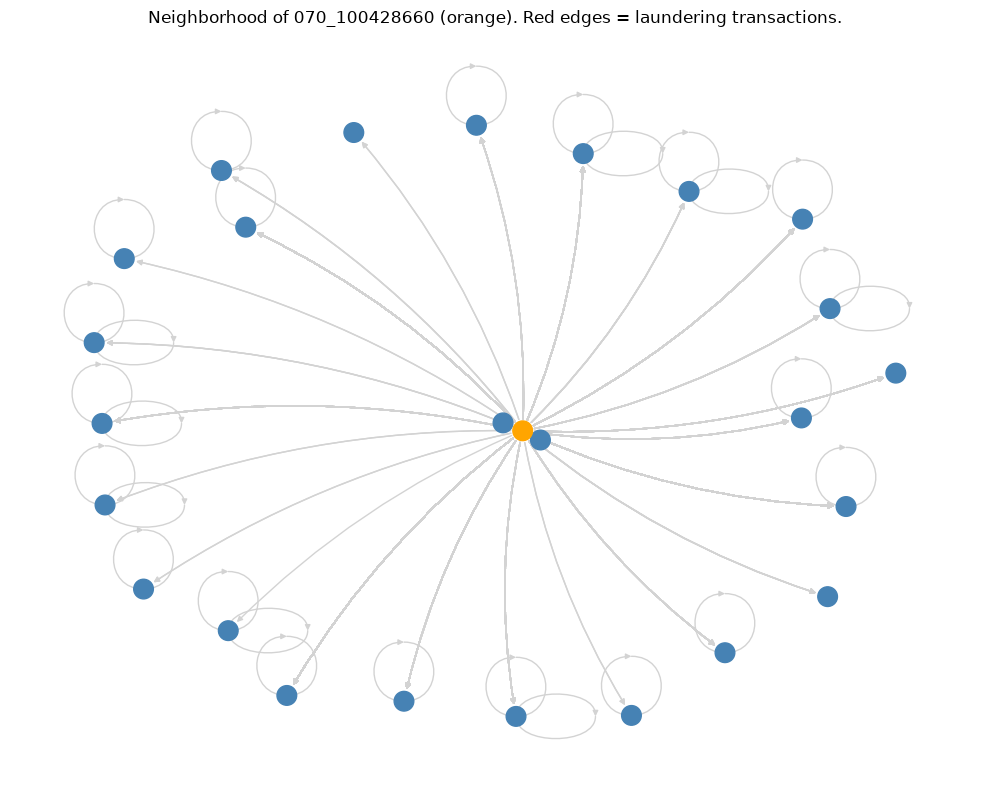

In [7]:
import matplotlib.pyplot as plt

# Look up a hub account by its human-readable Bank_Account id (from the earlier EDA).
# Falls back to the highest-degree node in the graph if that specific account isn't
# present in this run's node_to_idx (e.g. if you re-ran preprocessing on a different
# data snapshot).
target_node_str = "070_100428660"
if target_node_str in node_to_idx:
    center = node_to_idx[target_node_str]
else:
    degrees = dict(G.degree())
    center = max(degrees, key=degrees.get)
    print(f"'{target_node_str}' not found in this run -- using highest-degree node instead: {idx_to_node[center]}")

neighbors = set(G.successors(center)) | set(G.predecessors(center))
sample_neighbors = list(neighbors)[:25]  # cap for a readable plot
sub_nodes = [center] + sample_neighbors
subG = G.subgraph(sub_nodes)

edge_colors = []
for u, v, k in subG.edges(keys=True):
    mask = (edge_index[0] == u) & (edge_index[1] == v)
    is_laundering = labels[mask].max() if mask.any() else 0
    edge_colors.append("crimson" if is_laundering else "lightgray")

pos = nx.spring_layout(subG, seed=42)
plt.figure(figsize=(10, 8))
node_colors = ["orange" if n == center else "steelblue" for n in subG.nodes()]
nx.draw_networkx_nodes(subG, pos, node_color=node_colors, node_size=200)
nx.draw_networkx_edges(subG, pos, edge_color=edge_colors, arrows=True, arrowsize=8, connectionstyle="arc3,rad=0.1")
plt.title(f"Neighborhood of {idx_to_node[center]} (orange). Red edges = laundering transactions.")
plt.axis("off")
plt.tight_layout()
plt.savefig(DATA_DIR / "sample_neighborhood.png", dpi=120)
plt.show()


## 5. Build the PyTorch Geometric `Data` object

This is the actual model input for `train_gcn.ipynb`. Tensor dtypes matter here --
PyG expects `edge_index` as `torch.long` and features as `torch.float`.

In [8]:
import torch
from torch_geometric.data import Data

data = Data(
    x=torch.tensor(node_attr, dtype=torch.float),
    edge_index=torch.tensor(edge_index, dtype=torch.long),
    edge_attr=torch.tensor(edge_attr, dtype=torch.float),
    y=torch.tensor(labels, dtype=torch.long),
)

data.train_mask = torch.tensor(split_masks["train"], dtype=torch.bool)
data.val_mask = torch.tensor(split_masks["val"], dtype=torch.bool)
data.test_mask = torch.tensor(split_masks["test"], dtype=torch.bool)

# transaction_id is attached for traceability (mapping a prediction on edge i back to
# a human-facing ID later) but is a plain numpy array of strings, not a tensor -- it
# rides along on the Data object but is never used as a model input.
data.transaction_id = transaction_ids

# See Section 6 -- edge_attr[:, :edge_cat_start] are continuous/binary (-> Linear),
# edge_attr[:, edge_cat_start:] are categorical codes (-> nn.Embedding). Carried on
# the Data object itself so train_gcn.ipynb doesn't need to separately reload
# metadata.json just to split the columns correctly.
data.edge_cat_start = edge_cat_start

print(data)
data.validate(raise_on_error=True)
print("PyG Data object is valid.")


/home/jovyan/conda-envs/aml-gnn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Data(x=[2077023, 11], edge_index=[2, 31898218], edge_attr=[31898218, 21], y=[31898218], train_mask=[31898218], val_mask=[31898218], test_mask=[31898218], transaction_id=[31898218], edge_cat_start=18)
PyG Data object is valid.


## 6. Two modeling decisions this notebook deliberately leaves open for `train_gcn.ipynb`

Flagging these here rather than silently picking a default, since both affect model
behavior and neither has been explicitly decided yet:

**1. `GCNConv`'s automatic self-loops vs. our real self-loop transactions.**
A meaningful share of edges in this graph (~8% on the full HI-Medium file) are
*genuine* self-loop transactions (an account transacting with itself) that are
already present in `edge_index`. `GCNConv` by
default also adds its own self-loops (`add_self_loops=True`) for the symmetric
normalization the GCN propagation rule needs — this is a separate, purely
mathematical self-loop, not a transaction. Left on default, a node with a real
self-loop transaction would end up with *two* self-loops in the normalized adjacency
(one real, one synthetic), silently double-counting it relative to nodes without a
real self-loop. Decide explicitly in `train_gcn.ipynb`: either construct `GCNConv`
with `add_self_loops=False` and rely only on the real transaction self-loops, or keep
the default and treat the double-counting as acceptable/negligible — but pick one on
purpose.

**2. Directionality.**
`edge_index` here is directed (`src -> dst`, matching the real direction money moved).
Plain `GCNConv` propagation and its normalization were originally formulated for
undirected graphs. Training as-is means information only propagates along the
direction funds actually flowed; an alternative is to add reverse edges (with a
feature flag marking them as reverse, so the model can distinguish "sent to" from
"received from") so information flows both ways. This is a real modeling choice with
implications for what the GNN can learn — not something to default silently one way
or the other in this notebook.


## 7. Spot-check against the human-readable lookup table

Pick one transaction by its `transaction_id`, confirm the same row is retrievable identically from both the lookup table and the tensors that will actually feed the model — this is the exact retrieval path the FastAPI backend will use later, just checked here by hand.

In [9]:
sample_id = transaction_ids[0]
row_in_lookup = transactions_lookup[transactions_lookup["transaction_id"] == sample_id]
edge_position = np.where(transaction_ids == sample_id)[0][0]

print(f"transaction_id: {sample_id}")
print(f"\nFrom transactions_lookup.csv:")
print(row_in_lookup[["transaction_id", "src_node", "dst_node", "Amount Paid", "Is Laundering"]].to_string(index=False))

print(f"\nFrom the graph tensors at position {edge_position}:")
print(f"  src_idx -> dst_idx : {edge_index[0, edge_position]} -> {edge_index[1, edge_position]}")
print(f"  src_node -> dst_node: {idx_to_node[edge_index[0, edge_position]]} -> {idx_to_node[edge_index[1, edge_position]]}")
print(f"  label (Is Laundering): {labels[edge_position]}")

assert idx_to_node[edge_index[0, edge_position]] == row_in_lookup["src_node"].values[0]
assert idx_to_node[edge_index[1, edge_position]] == row_in_lookup["dst_node"].values[0]
assert labels[edge_position] == row_in_lookup["Is Laundering"].values[0]
print("\nMatch confirmed -- lookup table and graph tensors agree for this transaction_id.")


transaction_id: TXN00000000

From transactions_lookup.csv:
transaction_id           src_node           dst_node  Amount Paid  Is Laundering
   TXN00000000 03184493_846486F60 01187482_8464841F0      4224.24              0

From the graph tensors at position 0:
  src_idx -> dst_idx : 0 -> 1963959
  src_node -> dst_node: 03184493_846486F60 -> 01187482_8464841F0
  label (Is Laundering): 0

Match confirmed -- lookup table and graph tensors agree for this transaction_id.


## 7b. Optional — attach ground-truth pattern diagnostics (not a model input)

**Merged in from a teammate's exploratory notebook**, paired with the new
`pattern_diagnostics.csv` produced by Section 11 of `preprocessing.ipynb`. This attaches
each node's known ground-truth pattern type (if any) to the `Data` object purely as
ride-along metadata — the same pattern used for `transaction_id` above: a plain numpy
array, never a tensor, never touched by the model.

**Why attach it at all, if it's not a training input:** so that later, once PGExplainer
is producing edge-importance explanations, you can directly check a prediction's
explanation against the *known* scenario structure for that node (e.g. "PGExplainer
highlighted these 4 accounts as important — do they match the ground-truth FAN-OUT
this account was actually part of?"). That comparison is only possible if the ground
truth travels alongside the graph object; it's still never available to the GCN or to
PGExplainer itself.

**Carries the same collision caveat as Section 11 of `preprocessing.ipynb`:** the
patterns file keys accounts by raw `Account` only, not `Bank_Account`. The lookup below
is therefore best-effort (it splits each node's `Bank_Account` id and matches on the
raw account part) and can mismatch on the small number of accounts that collide across
banks. Fine for an approximate offline diagnostic; not something to rely on for a
specific node without double-checking against `pattern_diagnostics.csv` directly.

Skips cleanly if `pattern_diagnostics.csv` doesn't exist (e.g. `PARSE_PATTERNS_FILE`
was left `False` upstream).


In [10]:
pattern_diag_path = DATA_DIR / "pattern_diagnostics.csv"

if pattern_diag_path.exists():
    pattern_diagnostics = pd.read_csv(pattern_diag_path)
    # raw Account -> pattern_label / patterntype (best-effort, see caveat above)
    acct_to_label = dict(zip(pattern_diagnostics["account"], pattern_diagnostics["pattern_label"]))
    acct_to_type = dict(zip(pattern_diagnostics["account"], pattern_diagnostics["pattern_type"]))

    node_pattern_label = np.zeros(n_nodes, dtype="int8")
    node_pattern_type = np.array(["NORMAL"] * n_nodes, dtype=object)

    for node_str, idx in node_to_idx.items():
        raw_account = node_str.split("_", 1)[-1]  # Bank_Account -> Account (best-effort)
        if raw_account in acct_to_label:
            node_pattern_label[idx] = acct_to_label[raw_account]
            node_pattern_type[idx] = acct_to_type[raw_account]

    n_flagged = (node_pattern_label > 0).sum()
    print(f"Nodes matched to a ground-truth pattern: {n_flagged:,} / {n_nodes:,}")

    # Ride-along metadata only -- same treatment as transaction_id: attached to the
    # Data object for traceability, but plain numpy arrays, never fed to the model.
    data.node_pattern_label = node_pattern_label
    data.node_pattern_type = node_pattern_type
    print("Attached data.node_pattern_label / data.node_pattern_type (diagnostics only).")
else:
    print(f"{pattern_diag_path} not found -- skipping (Section 11 of preprocessing.ipynb "
          f"was likely run with PARSE_PATTERNS_FILE=False). Nothing downstream depends on this.")


Nodes matched to a ground-truth pattern: 22,279 / 2,077,023
Attached data.node_pattern_label / data.node_pattern_type (diagnostics only).


## 8. Save the graph object

In [11]:
torch.save(data, DATA_DIR / "graph_data.pt")
print(f"Saved PyG Data object to {DATA_DIR / 'graph_data.pt'}")
print(data)


Saved PyG Data object to /home/jovyan/AML_Project/Data/Bassam Data/graph_data.pt
Data(x=[2077023, 11], edge_index=[2, 31898218], edge_attr=[31898218, 21], y=[31898218], train_mask=[31898218], val_mask=[31898218], test_mask=[31898218], transaction_id=[31898218], edge_cat_start=18, node_pattern_label=[2077023], node_pattern_type=[2077023])


## Next step

Load `graph_data.pt` in `train_gcn.ipynb`. Remember it already carries `train_mask`,
`val_mask`, `test_mask`, and `y` -- the per-epoch negative subsampling (NEG_RATIO=10)
should sample from `data.edge_index[:, data.train_mask]` only, same as before. Resolve
the two open decisions in Section 6 (self-loops, directionality) explicitly at the top
of that notebook before building the model.
